In [1]:
import os
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

C:\Users\khanm\anaconda3\envs\t80_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

OUT_DIR = os.path.join(WORK_DIR, "artifacts", "07_shap")
os.makedirs(OUT_DIR, exist_ok=True)

X = pd.read_parquet(os.path.join(WORK_DIR, "interim", "X_features.parquet"))
y = pd.read_parquet(os.path.join(WORK_DIR, "interim", "y_target.parquet"))["T80_log1p"]
groups = pd.read_parquet(
    os.path.join(WORK_DIR, "interim", "groups.parquet")
)["Ref_DOI_number"]

print(X.shape, groups.nunique())

(1835, 77) 964


In [3]:
arch_feature_cols = [
    c for c in X.columns
    if (
        c in ["is_nip", "is_pin", "is_other_arch"]
        or c.startswith("architecture_family_")
    )
]

X_model = X.drop(columns=arch_feature_cols, errors="ignore").copy()

print("Final feature shape:", X_model.shape)

Final feature shape: (1835, 71)


In [4]:
def build_extreme_dataset(X, y, groups, low_q=0.25, high_q=0.75):
    q_low = y.quantile(low_q)
    q_high = y.quantile(high_q)

    mask = (y <= q_low) | (y >= q_high)

    X_sub = X.loc[mask].copy()
    y_sub = y.loc[mask].copy()
    g_sub = groups.loc[mask].copy()

    y_bin = (y_sub >= q_high).astype(int)

    return X_sub, y_bin, g_sub

X_cls, y_bin, g_cls = build_extreme_dataset(X_model, y, groups)

print("Samples:", len(X_cls), "DOI:", g_cls.nunique())

Samples: 921 DOI: 564


In [5]:
model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_cls, y_bin)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imp', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](71,)","['etl_has_tio2','etl_has_sno2','etl_has_pcbm',...,'light_bin_high_light', 'light_bin_missing','light_bin_other_rare']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,71
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of mi

In [6]:
# --- ROBUST SHAP PREPARATION ---

X_imp = model.named_steps["imp"].transform(X_cls)
X_imp_df = pd.DataFrame(X_imp, columns=X_cls.columns)

rf_model = model.named_steps["rf"]
explainer = shap.TreeExplainer(rf_model)

raw_shap = explainer.shap_values(X_imp_df)

print("type(raw_shap):", type(raw_shap))

# Handle different SHAP output formats
if isinstance(raw_shap, list):
    # old binary-classification format: [class0, class1]
    shap_values = raw_shap[1]

elif isinstance(raw_shap, np.ndarray):
    print("raw_shap.shape:", raw_shap.shape)

    if raw_shap.ndim == 3:
        # possible format: (n_samples, n_features, n_classes)
        if raw_shap.shape[2] == 2:
            shap_values = raw_shap[:, :, 1]
        # possible format: (n_samples, n_classes, n_features)
        elif raw_shap.shape[1] == 2:
            shap_values = raw_shap[:, 1, :]
        else:
            raise ValueError(f"Unexpected 3D SHAP shape: {raw_shap.shape}")

    elif raw_shap.ndim == 2:
        shap_values = raw_shap
    else:
        raise ValueError(f"Unexpected SHAP ndim: {raw_shap.ndim}")

else:
    raise ValueError(f"Unsupported SHAP output type: {type(raw_shap)}")

print("Final shap_values.shape:", shap_values.shape)
print("X_imp_df.shape:", X_imp_df.shape)

# Safety check for extra offset column
if shap_values.shape[1] == X_imp_df.shape[1] + 1:
    print("Detected extra offset column in SHAP values; removing last column.")
    shap_values = shap_values[:, :-1]

print("Adjusted shap_values.shape:", shap_values.shape)
print("Final X_imp_df.shape:", X_imp_df.shape)

assert shap_values.shape[0] == X_imp_df.shape[0]
assert shap_values.shape[1] == X_imp_df.shape[1]

type(raw_shap): <class 'numpy.ndarray'>
raw_shap.shape: (921, 71, 2)
Final shap_values.shape: (921, 71)
X_imp_df.shape: (921, 71)
Adjusted shap_values.shape: (921, 71)
Final X_imp_df.shape: (921, 71)


In [7]:
# --- FEATURE DOMAIN GROUPING ---

feature_groups = {}

for col in X_imp_df.columns:
    cl = col.lower()

    # Composition
    if any(k in cl for k in [
        "band_gap", "halide", "cation",
        "fa_", "ma_", "cs_", "br_", "i_", "cl_"
    ]):
        feature_groups[col] = "composition"

    # Device structure
    elif any(k in cl for k in [
        "perovskite_thickness",
        "etl_thickness",
        "htl_thickness",
        "thickness",
        "cell_area"
    ]):
        feature_groups[col] = "device_structure"

    # Transport layers / contacts
    elif any(k in cl for k in [
        "etl_", "htl_", "back_", "backcontact_",
        "spiro", "ptaa", "pedot", "niox",
        "pcbm", "c60", "tio2", "sno2", "zno"
    ]):
        feature_groups[col] = "transport_layers_contacts"

    # Stability-test conditions
    # IMPORTANT: this must come BEFORE "processing"
    elif any(k in cl for k in [
        "light",
        "protocol",
        "bias",
        "encapsulation",
        "is_dark",
        "is_high_light",
        "is_approx_1sun",
        "temperature_c",
        "rh_pct",
        "is_hot_test",
        "is_room_temperature",
        "is_humid_condition",
        "is_dry_condition"
    ]):
        feature_groups[col] = "stability_test_conditions"

    # Processing / fabrication
    elif any(k in cl for k in [
        "additive",
        "anneal",
        "process",
        "solvent",
        "fabrication"
    ]):
        feature_groups[col] = "processing"

    # Missingness flags
    elif "missing" in cl:
        feature_groups[col] = "missingness_flags"

    else:
        feature_groups[col] = "other"

# quick check
group_counts = pd.Series(feature_groups).value_counts()

print("Feature counts by domain:")
print(group_counts)

# Optional check of environmental variables
check_vars = [
    "temperature_c",
    "rh_pct",
    "is_hot_test",
    "is_room_temperature",
    "is_humid_condition",
    "is_dry_condition"
]

print("\nEnvironmental-variable domain check:")
for v in check_vars:
    if v in feature_groups:
        print(v, "->", feature_groups[v])

Feature counts by domain:
transport_layers_contacts    37
stability_test_conditions    28
device_structure              3
processing                    1
composition                   1
other                         1
Name: count, dtype: int64

Environmental-variable domain check:
temperature_c -> stability_test_conditions
rh_pct -> stability_test_conditions
is_hot_test -> stability_test_conditions
is_room_temperature -> stability_test_conditions
is_humid_condition -> stability_test_conditions
is_dry_condition -> stability_test_conditions


In [8]:
# ============================================================
# PUBLICATION LABELS + TOP FEATURES
# ============================================================

TOP_N = 12

friendly_names = {
    "protocol_has_d": "ISOS-D protocol",
    "protocol_family_isos_d": "Protocol family: ISOS-D",
    "temperature_c": "Temperature (°C)",
    "cell_area_measured_cm2": "Cell area (cm²)",
    "rh_pct": "Relative humidity (%)",
    "is_dark_condition": "Dark condition",
    "light_bin_dark_or_zero": "Dark/zero illumination",
    "is_hot_test": "High-temperature test",
    "htl_family_other_or_unknown": "HTL family: other/unknown",
    "light_intensity_suns": "Light intensity (suns)",
    "is_room_temperature": "Room-temperature test",
    "protocol_family_isos_l": "Protocol family: ISOS-L",
    "is_humid_condition": "Humid condition",
    "perovskite_thickness_nm": "Perovskite thickness (nm)",
    "protocol_has_l": "ISOS-L protocol",
    "is_high_light": "High-light condition",
    "has_perovskite_additives": "Perovskite additives",
    "is_dry_condition": "Dry condition",
    "light_bin_high_light": "High illumination",
    "has_htl_additives": "HTL additives"
}

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Sort features by importance
top_idx = np.argsort(mean_abs_shap)[::-1][:TOP_N]

# Subset SHAP matrix and feature dataframe
shap_top = shap_values[:, top_idx]
X_top = X_imp_df.iloc[:, top_idx].copy()

# Rename only for plotting
X_top.columns = [
    friendly_names.get(c, c.replace("_", " ").title())
    for c in X_top.columns
]

print("Top features used in publication figures:")
for i, name in enumerate(X_top.columns, 1):
    print(i, name)

Top features used in publication figures:
1 ISOS-D protocol
2 Protocol family: ISOS-D
3 Temperature (°C)
4 Cell area (cm²)
5 Relative humidity (%)
6 Dark condition
7 Dark/zero illumination
8 High-temperature test
9 HTL family: other/unknown
10 Light intensity (suns)
11 Room-temperature test
12 Humid condition


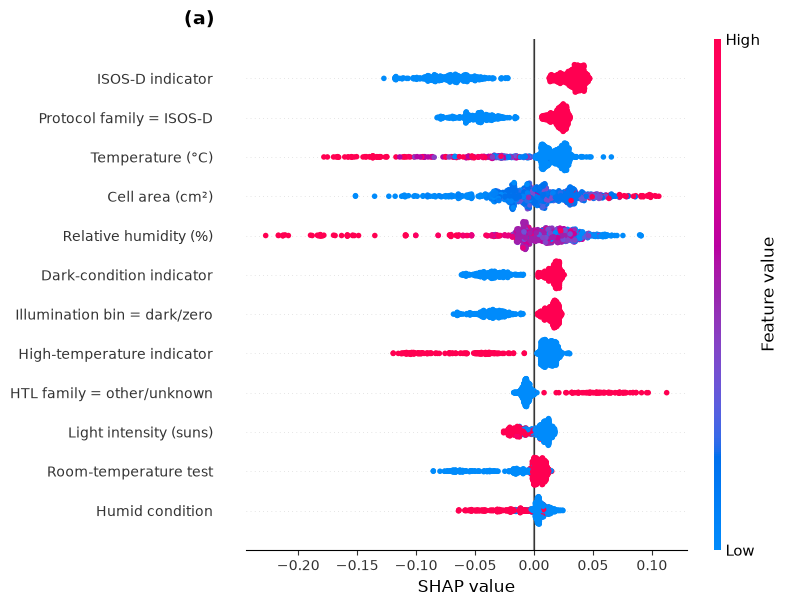


Figure saved successfully:
PDF: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\07_shap\Fig7a_SHAP_beeswarm_revised.pdf
PNG: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\07_shap\Fig7a_SHAP_beeswarm_revised.png


In [9]:
# ============================================================
# FIGURE 7(a) — PUBLICATION-QUALITY SHAP BEESWARM
# Reviewer-clarified labels
# ============================================================

import os
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# Check that SHAP results from the earlier analysis still exist
# ------------------------------------------------------------
required_vars = ["shap_top", "X_top", "TOP_N", "OUT_DIR"]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise RuntimeError(
        "These variables are not currently available: "
        + ", ".join(missing_vars)
        + "\nRun the earlier SHAP-calculation cell first, then rerun this cell."
    )

os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8
})

# ------------------------------------------------------------
# SHAP beeswarm
# ------------------------------------------------------------
plt.figure(figsize=(8.2, 6.2))

shap.summary_plot(
    shap_top,
    X_top,
    max_display=TOP_N,
    show=False,
    plot_size=None
)

ax = plt.gca()

# ------------------------------------------------------------
# Clarify overlapping feature names
# ------------------------------------------------------------
label_map = {
    "ISOS-D protocol":
        "ISOS-D indicator",

    "Protocol family: ISOS-D":
        "Protocol family = ISOS-D",

    "Dark condition":
        "Dark-condition indicator",

    "Dark/zero illumination":
        "Illumination bin = dark/zero",

    "High-temperature test":
        "High-temperature indicator",

    "Protocol family: ISOS-L":
        "Protocol family = ISOS-L",

    "HTL family: other/unknown":
        "HTL family = other/unknown"
}

old_labels = [tick.get_text() for tick in ax.get_yticklabels()]
new_labels = [label_map.get(x, x) for x in old_labels]

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(new_labels, fontsize=10)

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------
ax.set_xlabel("SHAP value", fontsize=12)
ax.set_ylabel("")

ax.axvline(
    0,
    color="black",
    linewidth=0.9,
    alpha=0.65,
    zorder=0
)

ax.tick_params(axis="x", labelsize=10)

# Panel label
ax.text(
    -0.14,
    1.02,
    "(a)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="bottom"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
pdf_path = os.path.join(
    OUT_DIR,
    "Fig7a_SHAP_beeswarm_revised.pdf"
)

png_path = os.path.join(
    OUT_DIR,
    "Fig7a_SHAP_beeswarm_revised.png"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully:")
print("PDF:", os.path.abspath(pdf_path))
print("PNG:", os.path.abspath(png_path))

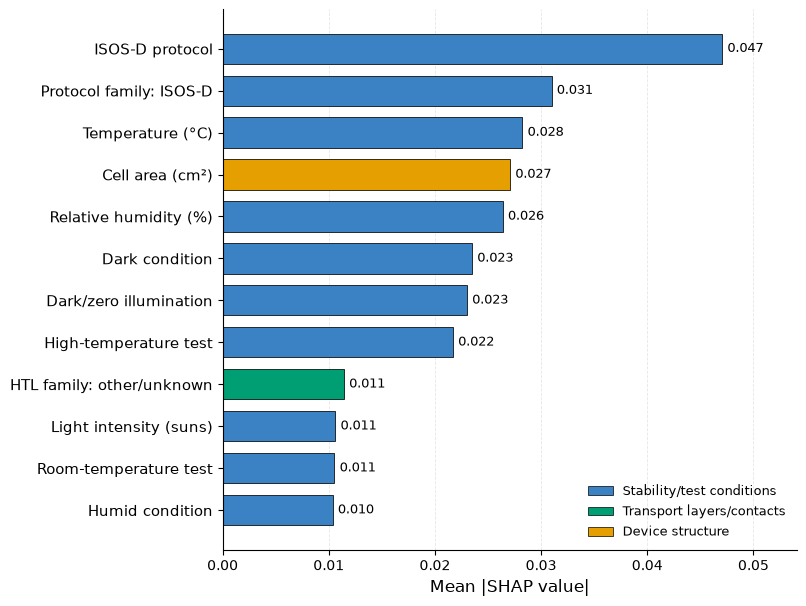

In [10]:
# ============================================================
# PUBLICATION-QUALITY SHAP IMPORTANCE
# Domain-coloured horizontal bar plot
# ============================================================

# Original feature names corresponding to top features
top_features_original = X_imp_df.columns[top_idx]

# Mean absolute SHAP importance
importance_top = mean_abs_shap[top_idx]

# Publication-friendly labels
publication_labels = [
    friendly_names.get(c, c.replace("_", " ").title())
    for c in top_features_original
]

# Get feature domain for each selected feature
top_domains = [
    feature_groups.get(c, "other")
    for c in top_features_original
]

# Build dataframe
bar_df = pd.DataFrame({
    "Feature": publication_labels,
    "Importance": importance_top,
    "Domain": top_domains
})

# Sort so most important appears at the top
bar_df = bar_df.sort_values(
    "Importance",
    ascending=True
).reset_index(drop=True)


# ============================================================
# DOMAIN COLOURS
# ============================================================

domain_colors = {
    "stability_test_conditions": "#3B82C4",       # blue
    "device_structure": "#E69F00",                # orange
    "transport_layers_contacts": "#009E73",       # green
    "processing": "#8E63CE",                      # purple
    "composition": "#C44E52",                     # reddish
    "missingness_flags": "#A0A0A0",               # light grey
    "other": "#6E6E6E"                            # dark grey
}

bar_colors = [
    domain_colors.get(domain, "#6E6E6E")
    for domain in bar_df["Domain"]
]


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(8.2, 6.2))

bars = ax.barh(
    bar_df["Feature"],
    bar_df["Importance"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.55,
    height=0.72
)

# Axis labels
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
ax.set_ylabel("")

# Tick formatting
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=11)

# Light vertical grid only
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

ax.set_axisbelow(True)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)


# ============================================================
# LEGEND — ONLY DOMAINS PRESENT IN THIS FIGURE
# ============================================================

from matplotlib.patches import Patch

domain_labels = {
    "stability_test_conditions": "Stability/test conditions",
    "device_structure": "Device structure",
    "transport_layers_contacts": "Transport layers/contacts",
    "processing": "Processing",
    "composition": "Composition",
    "missingness_flags": "Missingness",
    "other": "Other"
}

present_domains = bar_df["Domain"].unique()

legend_handles = [
    Patch(
        facecolor=domain_colors[d],
        edgecolor="black",
        linewidth=0.5,
        label=domain_labels[d]
    )
    for d in present_domains
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=False,
    fontsize=9
)


# ============================================================
# OPTIONAL VALUES AT END OF BARS
# ============================================================

for bar, value in zip(bars, bar_df["Importance"]):
    ax.text(
        value + 0.0005,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=9
    )

# Give space for numerical labels
ax.set_xlim(
    0,
    bar_df["Importance"].max() * 1.15
)

plt.tight_layout()


# ============================================================
# SAVE HIGH-QUALITY OUTPUTS
# ============================================================

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig_SHAP_importance_domain_colored.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig_SHAP_importance_domain_colored.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================================
# DOMAIN-LEVEL SHAP AGGREGATION
# ============================================================

# Mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Build feature-level SHAP dataframe
feature_shap_df = pd.DataFrame({
    "feature": X_imp_df.columns,
    "importance": mean_abs_shap,
    "domain": [feature_groups.get(c, "other") for c in X_imp_df.columns]
})

# Aggregate to domain level
domain_df = (
    feature_shap_df
    .groupby("domain", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(domain_df)

                      domain  importance
0  stability_test_conditions    0.302578
1  transport_layers_contacts    0.124002
2           device_structure    0.041899
3                 processing    0.009207
4                composition    0.005742
5                      other    0.000267


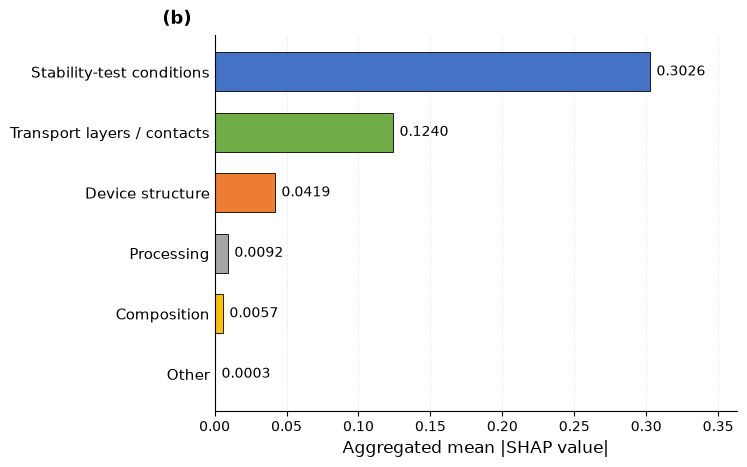

In [12]:
# ============================================================
# FIGURE 7(b) — PUBLICATION-QUALITY DOMAIN SHAP IMPORTANCE
# ============================================================

domain_plot = domain_df.copy()

friendly_names = {
    "stability_test_conditions": "Stability-test conditions",
    "transport_layers_contacts": "Transport layers / contacts",
    "device_structure": "Device structure",
    "processing": "Processing",
    "composition": "Composition",
    "other": "Other"
}

domain_plot["label"] = domain_plot["domain"].map(friendly_names)

# Ascending order gives the largest bar at the top
domain_plot = domain_plot.sort_values(
    "importance",
    ascending=True
).reset_index(drop=True)

# Different colors for each domain
colors = {
    "Stability-test conditions": "#4472C4",
    "Transport layers / contacts": "#70AD47",
    "Device structure": "#ED7D31",
    "Processing": "#A5A5A5",
    "Composition": "#FFC000",
    "Other": "#8064A2"
}

bar_colors = [colors[x] for x in domain_plot["label"]]

fig, ax = plt.subplots(figsize=(7.6, 4.8))

bars = ax.barh(
    domain_plot["label"],
    domain_plot["importance"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    height=0.65
)

ax.set_xlabel("Aggregated mean |SHAP value|", fontsize=12)
ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=11, length=0)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add values at ends of bars
xmax = domain_plot["importance"].max()

for bar, value in zip(bars, domain_plot["importance"]):
    ax.text(
        value + xmax * 0.015,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center",
        ha="left",
        fontsize=10
    )

ax.set_xlim(0, xmax * 1.20)

# Panel label
ax.text(
    -0.10,
    1.03,
    "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig7b_SHAP_domain_importance.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig7b_SHAP_domain_importance.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [13]:
# --- SAVE SHAP OUTPUTS ---

domain_df.to_csv(os.path.join(OUT_DIR, "07_domain_importance.csv"), index=False)

# Save top feature importance table
feature_importance_df = pd.DataFrame({
    "feature": X_imp_df.columns,
    "mean_abs_shap": np.abs(df_shap).mean(axis=0).values,
    "domain": [feature_groups[c] for c in X_imp_df.columns]
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

feature_importance_df.to_csv(os.path.join(OUT_DIR, "07_feature_importance.csv"), index=False)

print("Saved:", os.path.join(OUT_DIR, "07_domain_importance.csv"))
print("Saved:", os.path.join(OUT_DIR, "07_feature_importance.csv"))

feature_importance_df.head(20)

NameError: name 'df_shap' is not defined

In [ ]:
# --- SAVE SHAP METADATA CARD ---

card = {
    "notebook": "07_shap_analysis.ipynb",
    "input_shape": {
        "rows": int(X_imp_df.shape[0]),
        "cols": int(X_imp_df.shape[1])
    },
    "model": "RandomForestClassifier",
    "target_design": "Extreme classification (25_75), pooled_without_arch",
    "architecture_removed": True,
    "n_domains": int(domain_df.shape[0]),
    "top_10_features": feature_importance_df.head(10)["feature"].tolist(),
    "top_domains": domain_df["domain"].tolist()
}

card_path = os.path.join(OUT_DIR, "07_shap_card.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=4)

print("Saved:", card_path)
print("DONE.")

In [ ]:
importance = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(importance)[::-1]
top_features = X_imp_df.columns[sorted_idx[:3]]
print("Top 3 features:", top_features)

In [ ]:
for i, f in enumerate(top_features[0:3], start=1):

    shap.dependence_plot(
        f,
        shap_values,
        X_imp_df,
        show=False
    )

    filename = f"06E_shap_dependence_{i}_{f}.png"
    out = os.path.join(OUT_DIR, filename)

    plt.savefig(out, dpi=600)
    plt.show()

In [ ]:
# ============================================================
# PUBLICATION-QUALITY DOMAIN-LEVEL SHAP IMPORTANCE
# Figure 7(b)
# ============================================================

import matplotlib.pyplot as plt
import os

# Copy existing domain-level SHAP results
domain_plot = domain_df.copy()

# Publication-friendly domain names
friendly_domain_names = {
    "stability_test_conditions": "Stability-test conditions",
    "transport_layers_contacts": "Transport layers / contacts",
    "device_structure": "Device structure",
    "processing": "Processing",
    "composition": "Composition",
    "other": "Other"
}

domain_plot["label"] = domain_plot["domain"].map(friendly_domain_names)

# Sort smallest -> largest so largest appears at top in barh
domain_plot = domain_plot.sort_values(
    "importance",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# Distinct but publication-friendly colors
# ------------------------------------------------------------
domain_colors = {
    "Stability-test conditions": "#4472C4",      # blue
    "Transport layers / contacts": "#70AD47",    # green
    "Device structure": "#ED7D31",               # orange
    "Processing": "#A5A5A5",                     # grey
    "Composition": "#FFC000",                    # gold
    "Other": "#8064A2"                           # purple
}

bar_colors = [
    domain_colors[label]
    for label in domain_plot["label"]
]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.8))

bars = ax.barh(
    domain_plot["label"],
    domain_plot["importance"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.7,
    height=0.66
)

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------
ax.set_xlabel(
    "Aggregated mean |SHAP value|",
    fontsize=12,
    labelpad=8
)
ax.set_ylabel("")

ax.tick_params(
    axis="x",
    labelsize=10,
    direction="out"
)

ax.tick_params(
    axis="y",
    labelsize=11,
    length=0
)

# Light grid only along x-axis
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)
ax.set_axisbelow(True)

# Clean journal-style frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# ------------------------------------------------------------
# Numerical values at end of bars
# ------------------------------------------------------------
xmax = domain_plot["importance"].max()

for bar, value in zip(bars, domain_plot["importance"]):
    ax.text(
        value + xmax * 0.018,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=10
    )

# Extra horizontal space for value labels
ax.set_xlim(0, xmax * 1.20)

# ------------------------------------------------------------
# Panel label for combined Figure 7
# ------------------------------------------------------------
ax.text(
    -0.12,
    1.04,
    "(b)",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    va="top"
)

# Optional title:
# Better to omit if this is panel (b) of Figure 7
# ax.set_title("Domain-level SHAP importance", fontsize=13, pad=10)

plt.tight_layout()

# ------------------------------------------------------------
# Save publication-quality versions
# ------------------------------------------------------------
plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig7b_SHAP_domain_importance_publication.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig7b_SHAP_domain_importance_publication.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [ ]:
sample_idx = 5

if isinstance(explainer.expected_value, np.ndarray):
    if len(explainer.expected_value.shape) > 0:
        base_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        base_value = explainer.expected_value
else:
    base_value = explainer.expected_value

shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_value,
    data=X_imp_df.iloc[sample_idx],
    feature_names=X_imp_df.columns
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.tight_layout()
plt.show()

In [ ]:
top10_features = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_imp_df.columns
).sort_values(ascending=False).index[:10]

top10_shap_df = pd.DataFrame(shap_values, columns=X_imp_df.columns)[top10_features]

plt.figure(figsize=(10, 5))
plt.boxplot([top10_shap_df[col].dropna() for col in top10_features], tick_labels=top10_features, vert=True)

plt.ylabel("SHAP value", fontsize=11)
plt.title("Distribution of SHAP Values for Top 10 Features", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()